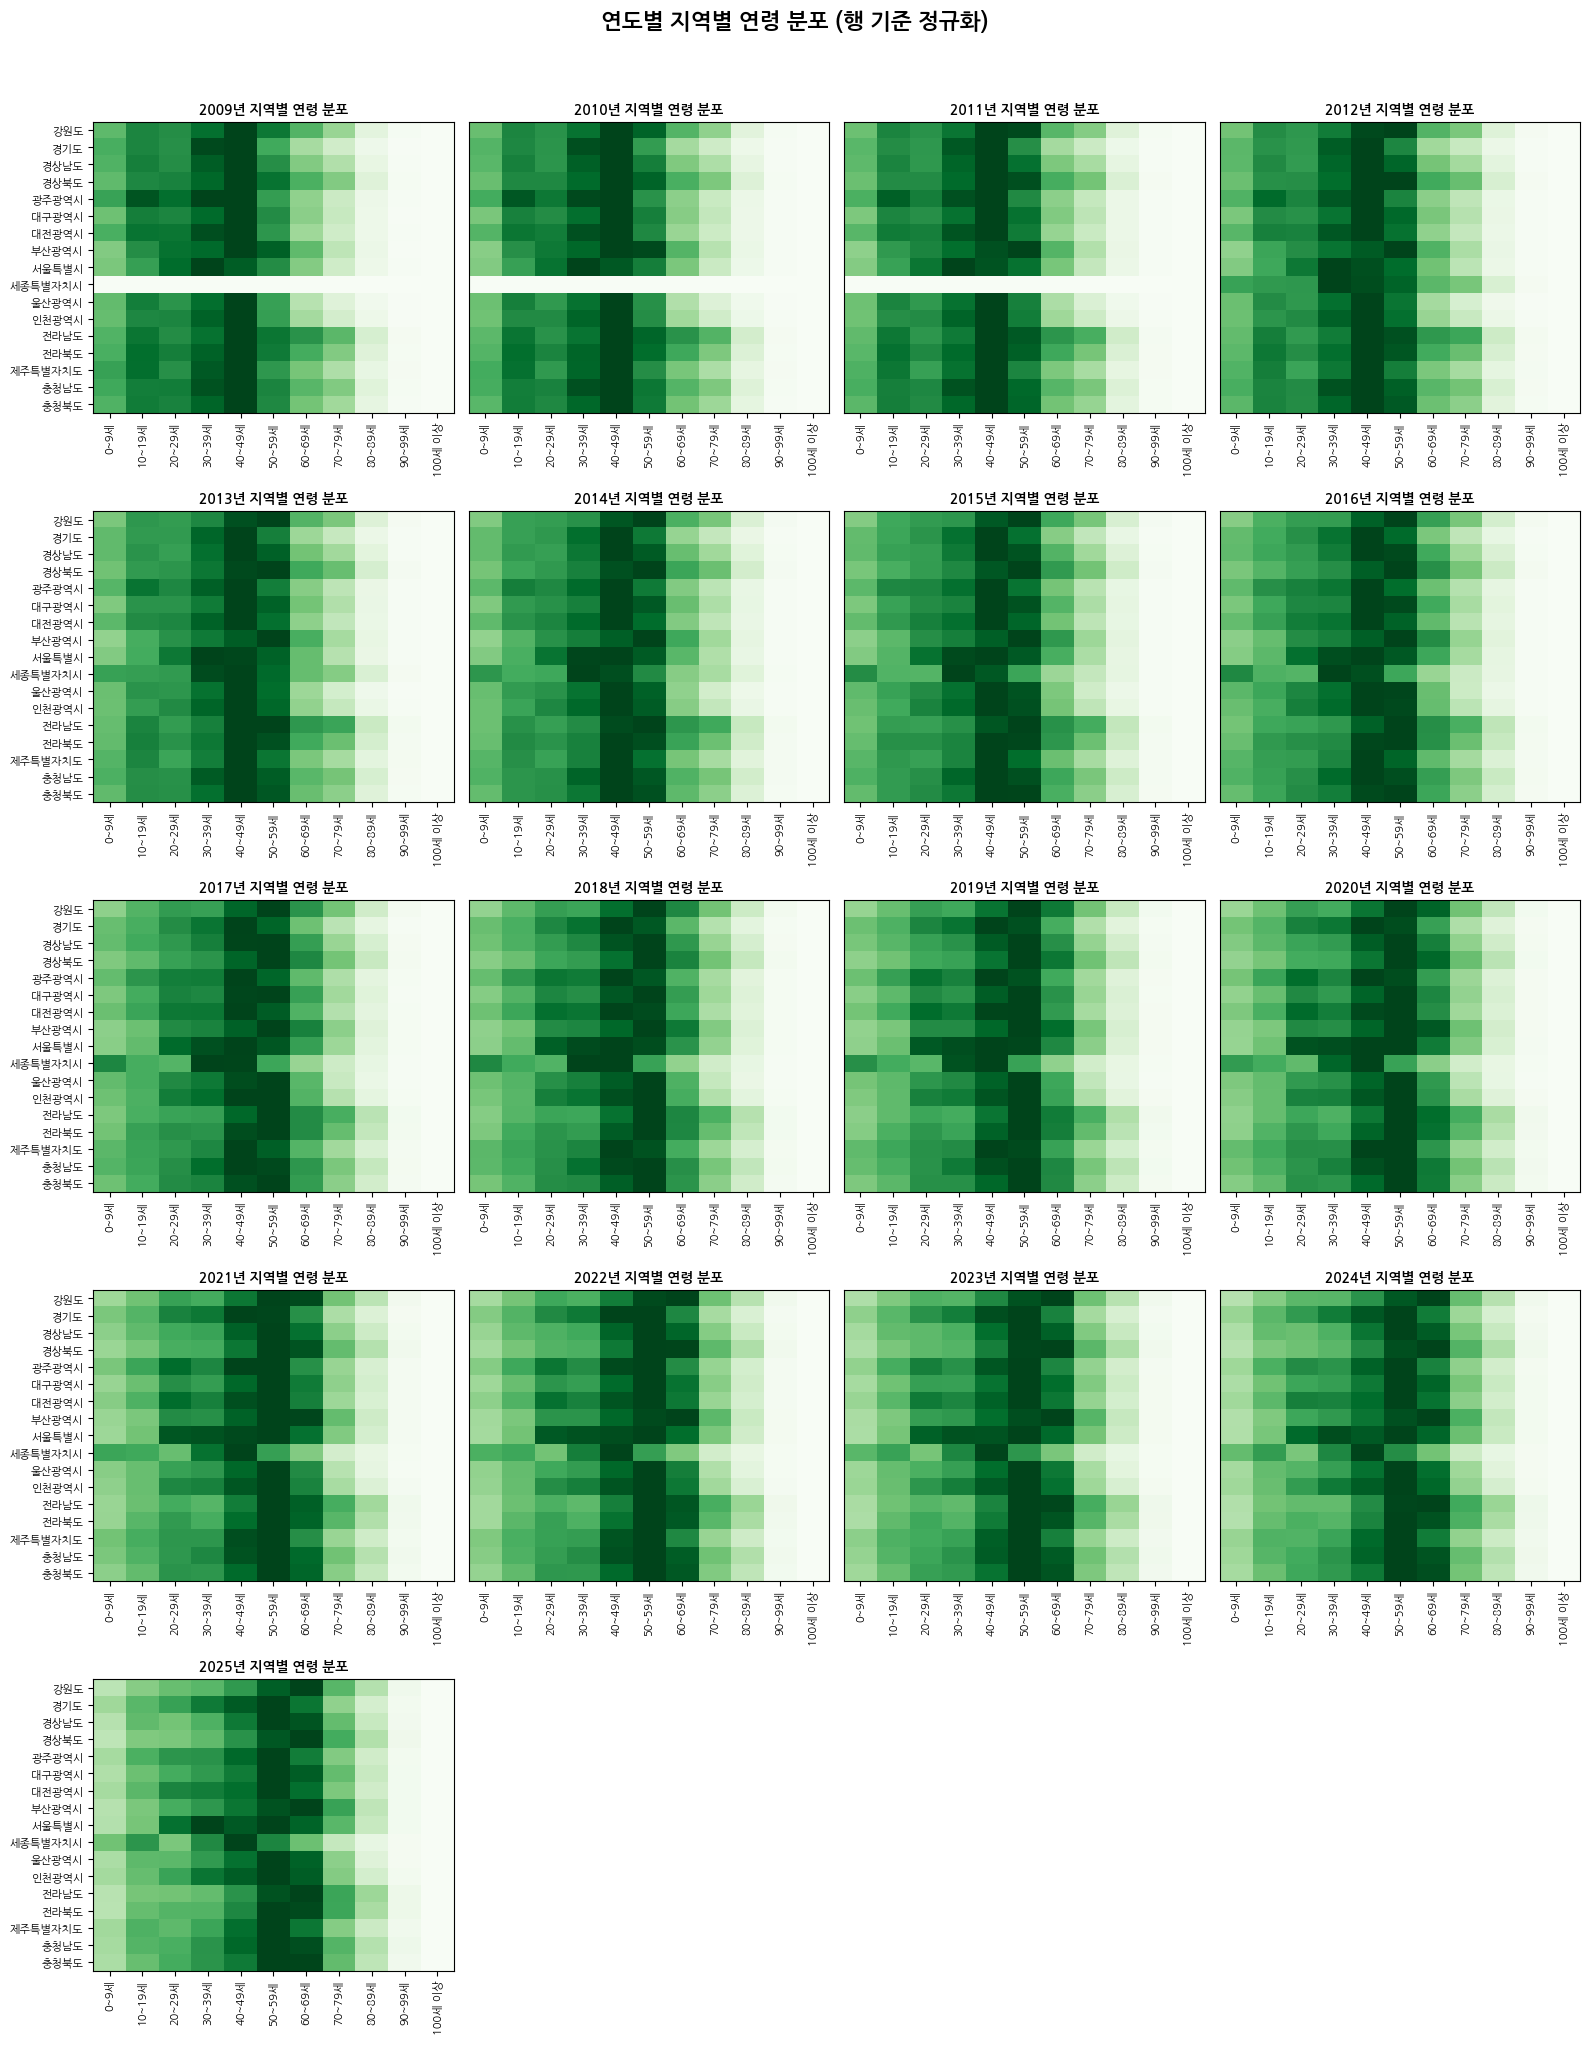

In [7]:
import os
import platform
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import urllib.request

# -----------------------------------------------------------------
# [강력 수정] 어떤 환경(Linux 서버, Mac, Windows)에서도 한글 깨짐을 막는 로직
# -----------------------------------------------------------------
def init_korean_font():
    os_name = platform.system()
    
    if os_name == 'Windows':
        plt.rcParams['font.family'] = 'Malgun Gothic'
    elif os_name == 'Darwin':  # macOS
        plt.rcParams['font.family'] = 'AppleGothic'
    else:  # Linux (현재 질문자님의 서버 환경)
        # 1. 시스템에 이미 설치된 나눔고딕 등이 있는지 먼저 체크
        available_fonts = [f.name for f in fm.fontManager.ttflist]
        korean_fonts = ['NanumGothic', 'NanumBarunGothic', 'Noto Sans CJK KR']
        
        font_set = False
        for font in korean_fonts:
            if font in available_fonts:
                plt.rcParams['font.family'] = font
                font_set = True
                break
                
        # 2. 시스템에 한글 폰트가 전혀 없다면 웹에서 폰트를 다운로드하여 동적 등록
        if not font_set:
            font_url = "https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf"
            font_path = "./NanumGothic_Server.ttf"
            
            # 파일이 없을 때만 최초 1회 다운로드
            if not os.path.exists(font_path):
                print("💡 시스템 한글 폰트가 없어 오픈소스 '나눔고딕'을 작업 디렉토리에 다운로드합니다...")
                urllib.request.urlretrieve(font_url, font_path)
                
            # 다운로드한 .ttf 파일을 Matplotlib 엔진에 강제로 연결
            fe = fm.FontEntry(fname=font_path, name='NanumGothicServer')
            fm.fontManager.ttflist.insert(0, fe)
            plt.rcParams['font.family'] = 'NanumGothicServer'

    # 마이너스 기호 깨짐 방지
    plt.rcParams['axes.unicode_minus'] = False

# 폰트 설정 실행
init_korean_font()


# 1. 파일 경로 탐색 (dist 폴더에서 실행되어도, 프로젝트 루트에서 실행되어도 동작하도록)
file_names = [
    "200912_201412_연령별인구현황_연간.csv",
    "201512_202012_연령별인구현황_연간.csv",
    "202112_202512_연령별인구현황_연간.csv",
]
search_dirs = ["dataset", "../dataset", "."]

def resolve_path(fname):
    for d in search_dirs:
        p = os.path.join(d, fname)
        if os.path.exists(p):
            return p
    raise FileNotFoundError(f"{fname} 파일을 찾을 수 없습니다.")

age_groups = ['0~9세','10~19세','20~29세','30~39세','40~49세','50~59세',
               '60~69세','70~79세','80~89세','90~99세','100세 이상']

# 2008년 이후 새 행정구역명 -> 기존 명칭으로 통합 (같은 지역 중복 방지)
region_alias = {'강원특별자치도': '강원도', '전북특별자치도': '전라북도'}

records = []
for fname in file_names:
    try:
        path = resolve_path(fname)
    except FileNotFoundError:
        print(f"경고: {fname} 파일을 찾을 수 없어 건너뜜.")
        continue
        
    df = pd.read_csv(path, encoding='cp949', thousands=',')
    # 100세이상 공백 통일 및 컬럼 정리
    df.columns = [c.strip().replace('100세이상', '100세 이상') for c in df.columns]

    df['행정구역'] = df['행정구역'].str.split('(').str[0].str.strip()
    df['행정구역'] = df['행정구역'].replace(region_alias)

    # 컬럼 구조에 유연하게 대응하여 연도 리스트 추출
    years = sorted({c[:4] for c in df.columns if '년_계_' in c and c[:4].isdigit()})

    for year in years:
        for age in age_groups:
            col = f"{year}년_계_{age}"
            if col not in df.columns:
                continue
            
            # Pandas 슬라이싱 warning 및 데이터 타입 에러 원천 차단
            tmp = df[['행정구역', col]].copy()
            tmp.columns = ['행정구역', 'pop']
            
            # 숫자가 문자열로 결합하는 현상을 막기 위한 강제 정수 변환
            tmp['pop'] = pd.to_numeric(tmp['pop'].astype(str).str.replace(',', ''), errors='coerce').fillna(0).astype(int)
            tmp['year'] = year
            tmp['age'] = age
            records.append(tmp)

if not records:
    raise ValueError("데이터를 로드하지 못했습니다. CSV 파일의 위치나 컬럼명을 확인해 주세요.")

long_df = pd.concat(records, ignore_index=True)
long_df = long_df[long_df['행정구역'] != '전국']

# 2. (지역, 연도, 연령대) 기준으로 합산 -> 행정구역명 변경으로 인한 중복 합치기
agg = long_df.groupby(['행정구역', 'year', 'age'], as_index=False)['pop'].sum()

regions = sorted(agg['행정구역'].unique())
years = sorted(agg['year'].unique())

# 3. 연도별 (지역 x 연령대) 피벗 테이블 생성
year_tables = {}
for year in years:
    sub = agg[agg['year'] == year]
    pivot = sub.pivot(index='행정구역', columns='age', values='pop')
    pivot = pivot.reindex(index=regions, columns=age_groups).fillna(0)
    year_tables[year] = pivot

# 4. 지역별 연령 분포 형태를 비교하기 위해 행(지역) 단위로 0~1 정규화
def row_normalize(df_):
    row_min = df_.min(axis=1)
    row_max = df_.max(axis=1)
    denom = row_max - row_min
    denom = denom.replace(0, 1)  # 0 나누기 방지
    return df_.sub(row_min, axis=0).div(denom, axis=0)

# 5. 연도별 히트맵을 4열 그리드로 시각화
ncols = 4
nrows = -(-len(years) // ncols)  # 올림 나눗셈

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 4), dpi=100)
axes = axes.flatten()

for i, year in enumerate(years):
    ax = axes[i]
    data = row_normalize(year_tables[year])
    ax.imshow(data.values, cmap='Greens', aspect='auto', vmin=0, vmax=1)

    ax.set_title(f'{year}년 지역별 연령 분포', fontsize=10, fontweight='bold')
    ax.set_xticks(range(len(age_groups)))
    ax.set_xticklabels(age_groups, rotation=90, fontsize=8)

    if i % ncols == 0:
        ax.set_yticks(range(len(regions)))
        ax.set_yticklabels(regions, fontsize=8)
    else:
        ax.set_yticks([])

# 남는 subplot 숨기기
for j in range(len(years), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('연도별 지역별 연령 분포 (행 기준 정규화)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()